# Exam

> Data: **2024-06-13**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Il dataset (preso da [Kaggle](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification?select=train.csv)) contiene dati relativi ad alcuni cellulari. Il dataset contiene diverse feature descritte di seguito, la variabile da predire è "price_range":

- `battery_power`: potenza della batteria (mAh)
- `blue`: ha il bluetooth oppure no (boolean)
- `clock_speed`: velocità del microprocessore
- `dual_sim`: ha il supporto dual sim oppure no (boolean)
- `fc`: mega pixels della telecamera frontale
- `four_g`: ha il 4G oppure no (boolean)
- `int_memory`: nemoria interna (GB)
- `m_dep`: Mobile Depth (cm)
- `mobile_wt`: peso
- `n_cores`: numero di core del processore
- `pc`: mega pixels della fotocamera esterna
- `px_height`: Pixel Resolution Height
- `px_width`: Pixel Resolution Width
- `ram`: RAM (MB)
- `sc_h`: altezza schermo (cm)
- `sc_w`: larghezza schermo (cm)
- `talk_time`: durata massima della batteria
- `three_g`: ha il 3G oppure no (boolean)
- `touch_screen`: ha il touch screen oppure no (boolean)
- `wifi`: ha il wifi oppure no (boolean)
- `price_range`: colonna target con valori 0 (costo basso), 1 (costo medio), 2 (costo alto), 3 (costo molto alto)

Note: Il file csv che si trova al [link](https://bit.ly/3xoah2F).

### Imports

In [1]:
# !curl -sLo dataset.zip "https://link"
# !unzip -o dataset.zip
# !mv file.csv dataset.csv
FILE_ID = "1H4vlfCyOzYjMu5mz_VpjIx6kIvPpHNwt"
!curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import FeatureUnion

### Dataset

In [3]:
df = pd.read_csv("dataset.csv")

#### Overview

In [4]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

#### Instances

In [6]:
df.shape

(2000, 21)

#### Missing values

In [7]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [8]:
df["price_range"].value_counts()

,count
price_range,
1,500
2,500
3,500
0,500


<Axes: >

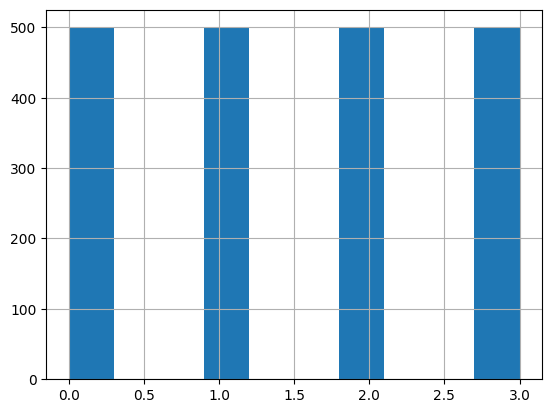

In [9]:
df["price_range"].hist()

##

---

## Parte 1: Analisi (Punti 10)

### Domanda 01 (Punti 1)

Quante sono le istanze contenute nel dataset? Il dataset è completo (cioè per ogni istanza tutti i valori di ogni attributo sono sempre correttamente specificati - non esistono "missing values")? Il dataset è bilanciato per quanto riguarda la classe da predire?

In [10]:
df.shape[0]

2000

> Il dataset contiene 2000 istanze.

In [11]:
df.isnull().sum().sum()

np.int64(0)

> Il dataset è completo, non contiene alcun missing value.

In [12]:
df["price_range"].value_counts()

,count
price_range,
1,500
2,500
3,500
0,500


> Il dataset risulta bilanciato per quanto riguarda la classe da predire `price_range`.

---

### Domanda 02 (Punti 3)

Considerare la feature `battery_power` e rappresentare con un istogramma la distribuzione dei valori. Raggruppare poi i valori secondo questa suddivisione: `gruppo1 501-800; gruppo2 801-1200; gruppo3 1201-1600; gruppo4 1601-1998`, visualizzare la distribuzione nei gruppi. Indicare per ogni gruppo il numero di istanze per ogni range di prezzo.

<Axes: ylabel='Frequency'>

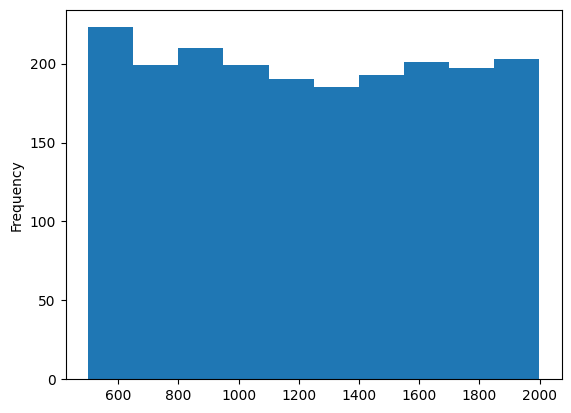

In [13]:
df["battery_power"].plot(kind="hist")

In [14]:
bins = [500, 800, 1200, 1600, 1998]
battery_power_bins = pd.cut(df["battery_power"], bins=bins)
battery_power_bins.value_counts()

,count
battery_power,
"(800, 1200]",545
"(1600, 1998]",519
"(1200, 1600]",514
"(500, 800]",422


<Axes: ylabel='Frequency'>

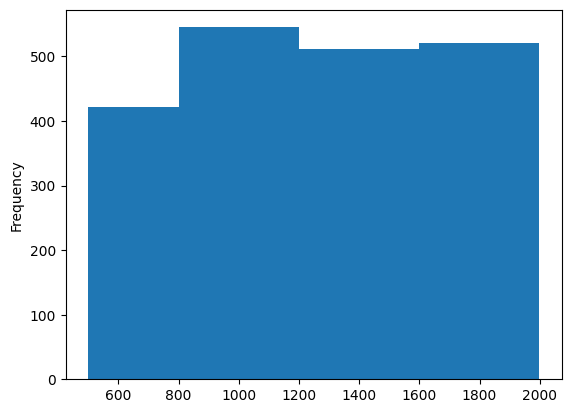

In [15]:
df["battery_power"].plot(kind="hist", bins=bins)

---

### Domanda 03 (Punti 4)

Considerare solo i cellulari che hanno il 4G e una RAM superiore (>) a 2 GB (2048 MB). Rappresentare in uno scatterplot i valori di ram (ascisse) e memoria interna (ordinate). Colorare i punti nel grafico in base al valore della colonna `price_range`. Usare i nomi dei due attributi come etichette dell’asse delle ascisse e dell’asse delle ordinate.

<Axes: xlabel='ram', ylabel='int_memory'>

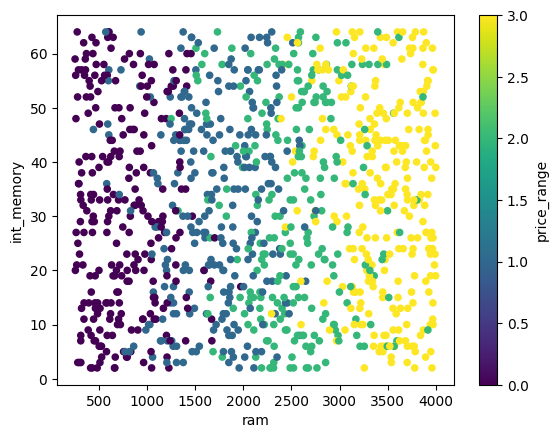

In [16]:
mask_4g = df["four_g"] == 1
mask_2_ram = df["ram"] > 2
df[mask_4g & mask_2_ram].plot(kind="scatter", x="ram", y="int_memory", c="price_range", colormap="viridis")

---

### Domanda 04 (Punti 2)

Realizzare una tabella pivot in cui rappresentare il numero di cellulari per ogni range di prezzo (variabile sulle colonne) considerando sulle righe le variabili `touch_screen` e `int_memory` (suddivisa in 5 gruppi).

In [17]:
index = [df["touch_screen"], pd.cut(df["int_memory"], bins=5)]
pd.pivot_table(df, index=index, columns="price_range", aggfunc="size", observed=False)

price_range                  0   1   2   3
touch_screen int_memory                   
0            (1.938, 14.4]  53  49  56  52
             (14.4, 26.8]   46  43  53  50
             (26.8, 39.2]   47  56  52  53
             (39.2, 51.6]   35  51  49  50
             (51.6, 64.0]   57  40  55  47
1            (1.938, 14.4]  71  61  68  44
             (14.4, 26.8]   48  49  44  43
             (26.8, 39.2]   56  51  42  44
             (39.2, 51.6]   44  52  42  63
             (51.6, 64.0]   43  48  39  54

##

---

## Parte 2: Trasformazione e Predizione (Punti 20)

### Domanda 01 (Punti 4)

Si vuole predire il valore di range di prezzo sulla base degli attributi presenti nel dataset. Ricaricare il dataset originale, eliminare eventuali attributi inutili (giustificare la scelta), eliminare le eventuali istanze che contengono valori nulli, e dividere il dataset in modo che 3/4 degli elementi siano contenuti in un nuovo dataset "train" e 1/4 nel dataset "test" preservando le proporzioni delle classi nella colonna target.

Allenare il train con il modello DecisionTree e valutare l'accuracy ottenuta calcolata sia sul dataset train sia sul dataset test. Confrontare i risultati ottenuti con quelli ottenuti con una predizione basata sul modello KNeighborsClassifier. Effettuare alcune considerazioni sui risultati ottenuti, tenendo in considerazione anche l'analisi della confusion matrix e la predizione effettuata da un dummy classifier a scelta.

In [18]:
df = pd.read_csv("dataset.csv")
df.dropna(inplace=True)

> Non è necessario rimuovere alcun attributo dal dataset, risultano tutti potenzialmente importanti e nessuno comporta dei pattern errati di predizione.

In [19]:
X, y = df.drop("price_range", axis=1), df["price_range"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [20]:
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=0),
    "KNeighbors": KNeighborsClassifier(),
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=0)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print(name)
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(y_train, y_train_pred))
    print(confusion_matrix(y_train, y_train_pred))
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))
    print("=" * 30)
    print()

DecisionTree
TRAIN
    Accuracy: 1.0
[[375   0   0   0]
 [  0 375   0   0]
 [  0   0 375   0]
 [  0   0   0 375]]
------------------------------
TEST
    Accuracy: 0.828
[[115  10   0   0]
 [  6 106  13   0]
 [  0  23  90  12]
 [  0   1  21 103]]

KNeighbors
TRAIN
    Accuracy: 0.9473333333333334
[[366   9   0   0]
 [  9 360   6   0]
 [  0  18 340  17]
 [  0   0  20 355]]
------------------------------
TEST
    Accuracy: 0.908
[[122   3   0   0]
 [  7 112   6   0]
 [  0  10 107   8]
 [  0   0  12 113]]

Dummy
TRAIN
    Accuracy: 0.25
[[375   0   0   0]
 [375   0   0   0]
 [375   0   0   0]
 [375   0   0   0]]
------------------------------
TEST
    Accuracy: 0.25
[[125   0   0   0]
 [125   0   0   0]
 [125   0   0   0]
 [125   0   0   0]]



> I due modelli `DecisionTree` e `KNeighbors` presentano dei valori di accuracy abbastanza alte. Il primo arriva a 82% sul dataset di test, mentre il secondo tocca addirittura 90% sempre sul dataset di test.
>
> Il modello `Dummy` è stato addestrato con la strategia di predire sempre la classe più frequente, quindi effettua sempre la stessa predizione, senza basarsi su nessun dato di train. Questo porta ovviamente ad avere performance decisamente scadenti, in quanto effettua predizioni a priori.
>
> Dalla confusion matrix possiamo notare come gli errori commessi dai modelli risultino abbastanza bilanciati, senza avere nessuna classe in particolare nel quale i modelli effettuano errori in particolare nella predizione.

---

### Domanda 02 (Punti 1)

Confrontare l'accuratezza ottenuta nel punto precedente con l'accuratezza che si ottiene con una 10 Fold cross validation.

In [21]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=10)
    print(name)
    print("=" * 30)
    print("    Score mean:", scores.mean())
    print("    Scores:", scores)
    print("=" * 30)
    print()

DecisionTree
    Score mean: 0.8385
    Scores: [0.845 0.86  0.86  0.805 0.855 0.85  0.855 0.81  0.85  0.795]

KNeighbors
    Score mean: 0.9235000000000001
    Scores: [0.9   0.94  0.92  0.935 0.925 0.95  0.915 0.915 0.915 0.92 ]

Dummy
    Score mean: 0.25
    Scores: [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25]



> I nuovi valori di accuracy che otteniamo dai modelli attraverso il 10 fold cross validation risultano leggermente migliori rispetto a quelli ottenuti al punto precedente, anche se solo di un paio di punti percentuali.

---

### Domanda 03 (Punti 3)

Trovare i parametri migliori del classificatore DecisionTree. Agire sui parametri criterion e min_samples_leaf. Verificare se l'accuratezza che si ottiene con la nuova configurazione supera quella ottenuta con i parametri di default al punto 1.

In [22]:
decision_tree = models["DecisionTree"]

params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "min_samples_leaf": [1, 2, 3, 4, 5],
}
grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best params: {'criterion': 'entropy', 'min_samples_leaf': 1}
Best score: 0.8486666666666667
Accuracy: 0.856
[[110  15   0   0]
 [  8 111   6   0]
 [  0  12  97  16]
 [  0   0  15 110]]


> Si, ottenendo i parametri ottimali per il modello `DecisionTree`, ovvero `criterion: entropy` e `min_samples_leaf: 1`, il modello ottiene una accuracy leggermente migliore rispetto a quella ottenuta nel primo punto, anche se di un punto percentuale.

---

### Domanda 04 (Punti 3)

Studiare la correlazione tra tutte le feature del dataset, creare un dataframe che contiene, oltre alla colonna target, le 5 feature più correlate (positivamente) al target. Ripetere la classificazione sul nuovo dataset e verificare se l’accuratezza ottenuta con DecisionTree e KNeighborsClassifier migliora.

In [23]:
correlation = df.corr()["price_range"].sort_values(ascending=False)[:6]
correlation

,price_range
price_range,1.000000
ram,0.917046
battery_power,0.200723
px_width,0.165818
px_height,0.148858
int_memory,0.044435


In [24]:
df_correlation = df[correlation.index]
df_correlation.head()

,price_range,ram,battery_power,px_width,px_height,int_memory
0,1,2549,842,756,20,7
1,2,2631,1021,1988,905,53
2,2,2603,563,1716,1263,41
3,2,2769,615,1786,1216,10
4,1,1411,1821,1212,1208,44


In [25]:
X, y = df_correlation.drop("price_range", axis=1), df_correlation["price_range"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [26]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print(name)
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(y_train, y_train_pred))
    print(confusion_matrix(y_train, y_train_pred))
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))
    print("=" * 30)
    print()

DecisionTree
TRAIN
    Accuracy: 1.0
[[375   0   0   0]
 [  0 375   0   0]
 [  0   0 375   0]
 [  0   0   0 375]]
------------------------------
TEST
    Accuracy: 0.844
[[116   9   0   0]
 [  8 107  10   0]
 [  0  18  92  15]
 [  0   0  18 107]]

KNeighbors
TRAIN
    Accuracy: 0.946
[[365  10   0   0]
 [ 10 359   6   0]
 [  0  18 339  18]
 [  0   0  19 356]]
------------------------------
TEST
    Accuracy: 0.91
[[122   3   0   0]
 [  7 112   6   0]
 [  0  10 107   8]
 [  0   0  11 114]]

Dummy
TRAIN
    Accuracy: 0.25
[[375   0   0   0]
 [375   0   0   0]
 [375   0   0   0]
 [375   0   0   0]]
------------------------------
TEST
    Accuracy: 0.25
[[125   0   0   0]
 [125   0   0   0]
 [125   0   0   0]
 [125   0   0   0]]



> Confrontando i risultati ottenuti con i risultati dei modelli al punto 1, questo nuovo dataset consente di ottenere valori di accuracy maggiori rispetto alle precedenti. Infatti il `DecisionTree` tocca l'84% di accuracy, mentre il `KNeighbors` il 91% di accuracy, entrambi sul dataset di test. Il `DecisionTree` quasi pareggia l'accuracy ottenuta dal modello con parametri ottimali.

---

### Domanda 05 (Punti 3)

Creare una pipeline in cui gli attributi `int_memory`, `ram` e `talk_time` sono scalati in modo che abbiano media 0 e varianza 1, gli attributi `mobile_wt` e `battery_power` sono discretizzati in 5 intervalli, e tutti gli altri attributi sono lasciati invariati. La pipeline deve applicare il modello DecisionTree con i parametri migliori trovati al punto 2. Valutare l'accuratezza della classificazione.

In [27]:
df = pd.read_csv("dataset.csv")
df.dropna(inplace=True)

In [28]:
X, y = df.drop("price_range", axis=1), df["price_range"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [29]:
discretizer = KBinsDiscretizer(n_bins=5, random_state=0)
scaler = StandardScaler()

column_transformer = ColumnTransformer(
    transformers=[
        ("discretizer", discretizer, ["mobile_wt", "battery_power"]),
        ("scaler", scaler, ["int_memory", "ram", "talk_time"]),
    ],
    remainder="passthrough",
    force_int_remainder_cols=False,
)
column_transformer

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('discretizer',
                                 KBinsDiscretizer(random_state=0),
                                 ['mobile_wt', 'battery_power']),
                                ('scaler', StandardScaler(),
                                 ['int_memory', 'ram', 'talk_time'])])

In [30]:
best_criterion = grid_search.best_params_["criterion"]
best_min_samples_leaf = grid_search.best_params_["min_samples_leaf"]
decision_tree = DecisionTreeClassifier(
    criterion=best_criterion,
    min_samples_leaf=best_min_samples_leaf,
    random_state=0,
)

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(random_state=0),
                                                  ['mobile_wt',
                                                   'battery_power']),
                                                 ('scaler', StandardScaler(),
                                                  ['int_memory', 'ram',
                                                   'talk_time'])])),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy', random_state=0))])

In [31]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.838
[[114  11   0   0]
 [ 11 104  10   0]
 [  0  14  94  17]
 [  0   0  18 107]]


> L'accuratezza ottenuta dalla pipeline è abbastanza decente, una accuratezza quasi del 84%, ma risulta essere leggermente inferiore a quella ottenuta al punto precedente e anche rispetto a quella del punto ancora prima.

---

### Domanda 06 (Punti 3)

Aggiungere alla pipeline del punto 5 la funzione SelectKBest. Utilizzare la funzione di gridSearchCV per selezionare il K migliore e anche il numero migliore di bin in cui discretizzare i valori di `mobile_wt` e `battery_power` (scegliere a piacere alcuni valori).

In [32]:
k_best = SelectKBest()

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("k_best", k_best),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(random_state=0),
                                                  ['mobile_wt',
                                                   'battery_power']),
                                                 ('scaler', StandardScaler(),
                                                  ['int_memory', 'ram',
                                                   'talk_time'])])),
                ('k_best', SelectKBest()),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy', random_state=0))])

In [34]:
params = {
    "k_best__k": [1, 2, 3, 4, 5],
    "column_transformer__discretizer__n_bins": [2, 5, 10, 15],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best params: {'column_transformer__discretizer__n_bins': 2, 'k_best__k': 5}
Best score: 0.8533333333333333
Accuracy: 0.87
[[117   8   0   0]
 [  8 109   8   0]
 [  0  15 100  10]
 [  0   0  16 109]]


---

### Domanda 07 (Punti 3)

Creare una nuova pipeline che applica la decomposizione TruncatedSVD (simile alla PCA) al dataset iniziale e aggiunge le componenti ottenute alla pipeline del punto 5. Valutare il valore migliore per il numero di componenti di TruncatedSVD tra 2, 4 e 6.

In [37]:
svd = TruncatedSVD(random_state=0)

feature_union = FeatureUnion(
    transformer_list=[
        ("svd", svd),
        ("column_transformer", column_transformer),
    ],
)
feature_union

FeatureUnion(transformer_list=[('svd', TruncatedSVD(random_state=0)),
                               ('column_transformer',
                                ColumnTransformer(force_int_remainder_cols=False,
                                                  remainder='passthrough',
                                                  transformers=[('discretizer',
                                                                 KBinsDiscretizer(random_state=0),
                                                                 ['mobile_wt',
                                                                  'battery_power']),
                                                                ('scaler',
                                                                 StandardScaler(),
                                                                 ['int_memory',
                                                                  'ram',
                                                                  'talk_time'])]))])

In [38]:
pipeline = Pipeline(
    steps=[
        ("feature_union", feature_union),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('feature_union',
                 FeatureUnion(transformer_list=[('svd',
                                                 TruncatedSVD(random_state=0)),
                                                ('column_transformer',
                                                 ColumnTransformer(force_int_remainder_cols=False,
                                                                   remainder='passthrough',
                                                                   transformers=[('discretizer',
                                                                                  KBinsDiscretizer(random_state=0),
                                                                                  ['mobile_wt',
                                                                                   'battery_power']),
                                                                                 ('scaler',
                                                                                  StandardScaler(),
                                                                                  ['int_memory',
                                                                                   'ram',
                                                                                   'talk_time'])]))])),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy', random_state=0))])

In [39]:
params = {
    "feature_union__svd__n_components": [2, 4, 6],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best params: {'feature_union__svd__n_components': 6}
Best score: 0.9440000000000002
Accuracy: 0.95
[[123   2   0   0]
 [  5 116   4   0]
 [  0   7 115   3]
 [  0   0   4 121]]


> Attraverso questa ultima pipeline, il modello `DecisionTree` ottiene un valore di accuratezza pari al 94%, il più alto ottenuto rispetto a tutti i valori precedenti. Inoltre, non sono stati utilizzati neanche il valore ottimale di `n_bins` per il `KBinsDiscretizer`.